# Location / Market Analysis

**Objective:** How do retail food prices differ across Ethiopian markets?


## 1. Load the Data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create images dir if it doesn't exist
os.makedirs('../images', exist_ok=True)

df = pd.read_csv('../data/processed/clean_prices.csv')

print("Head:")
display(df.head())
print("\nShape:", df.shape)
print("\nInfo:")
df.info()


Head:


,country,market,admin_1,longitude,latitude,cpcv2,product,source_document,period_date,price_type,product_source,unit,unit_type,currency,value
0,Ethiopia,"Addis Ababa, Merkato",Addis Ababa,38.7667,9.03333,R01701BD,Beans (Haricot),Famine Early Warning Systems Network (FEWS NET...,2020-01-01,Retail,Local,kg,Weight,ETB,41.0
1,Ethiopia,"Addis Ababa, Merkato",Addis Ababa,38.7667,9.03333,R01701BD,Beans (Haricot),Famine Early Warning Systems Network (FEWS NET...,2020-01-08,Retail,Local,kg,Weight,ETB,46.0
2,Ethiopia,"Addis Ababa, Merkato",Addis Ababa,38.7667,9.03333,R01701BD,Beans (Haricot),Famine Early Warning Systems Network (FEWS NET...,2020-01-15,Retail,Local,kg,Weight,ETB,48.6
3,Ethiopia,"Addis Ababa, Merkato",Addis Ababa,38.7667,9.03333,R01701BD,Beans (Haricot),Famine Early Warning Systems Network (FEWS NET...,2020-01-22,Retail,Local,kg,Weight,ETB,49.0
4,Ethiopia,"Addis Ababa, Merkato",Addis Ababa,38.7667,9.03333,R01701BD,Beans (Haricot),Famine Early Warning Systems Network (FEWS NET...,2020-01-29,Retail,Local,kg,Weight,ETB,50.0



Shape: (32504, 15)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32504 entries, 0 to 32503
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          32504 non-null  object 
 1   market           32504 non-null  object 
 2   admin_1          32504 non-null  object 
 3   longitude        32504 non-null  float64
 4   latitude         32504 non-null  float64
 5   cpcv2            32504 non-null  object 
 6   product          32504 non-null  object 
 7   source_document  32504 non-null  object 
 8   period_date      32504 non-null  object 
 9   price_type       32504 non-null  object 
 10  product_source   32504 non-null  object 
 11  unit             32504 non-null  object 
 12  unit_type        32504 non-null  object 
 13  currency         32504 non-null  object 
 14  value            32504 non-null  float64
dtypes: float64(3), object(12)
memory usage: 3.7+ MB


## 2. Check Market Observations


In [2]:
market_obs = df['market'].value_counts().reset_index()
market_obs.columns = ['market', 'number_of_observations']
market_obs = market_obs.sort_values(by='number_of_observations', ascending=False)
display(market_obs)


,market,number_of_observations
0,"Addis Ababa, Merkato",2138
1,"Nazareth, Adama",1945
2,Shashemene,1852
3,Sikela,1801
4,Yabelo,1770
5,Chereti,1740
6,Gode,1737
7,Bahir Dar,1683
8,Jinka,1683
9,Warder,1673


Observation count matters when comparing markets because markets with very few observations might have average prices skewed by outliers or missing data for certain time periods or commodities. Comparing markets with thousands of observations to a market with a few hundred observations might not be an apples-to-apples comparison.


## 3. Average Price by Market


In [3]:
avg_price_market = df.groupby('market')['value'].mean().reset_index()
avg_price_market.columns = ['market', 'average_price_etb_per_kg']
avg_price_market = avg_price_market.sort_values(by='average_price_etb_per_kg', ascending=False)
display(avg_price_market)


,market,average_price_etb_per_kg
20,Warder,68.732407
9,Gode,51.685320
1,Awash,48.418544
11,Logia,48.089004
5,Degehabour,45.757428
0,"Addis Ababa, Merkato",43.379878
4,Chereti,42.230230
7,"Dire Dawa, Kezira",40.870729
2,Bahir Dar,39.588197
16,Shashemene,37.902160


## 4. Select Common Commodities


In [4]:
markets_per_commodity = df.groupby('product')['market'].nunique().reset_index(name='num_markets')
markets_per_commodity = markets_per_commodity.sort_values(by='num_markets', ascending=False)
display(markets_per_commodity.head(10))

# Selecting top 4 food commodities that are available in all 22 markets
selected_commodities = ['Maize Grain (White)', 'Refined sugar', 'Sorghum (White)', 'Wheat Grain']
print("Selected Commodities:", selected_commodities)


,product,num_markets
3,Maize Grain (White),22
5,Refined sugar,22
8,Sorghum (White),22
11,Wheat Grain,22
1,Firewood,21
6,Rice (Milled),21
0,Beans (Haricot),20
2,Horse beans,20
7,Sorghum (Red),20
4,Mixed Teff,19


Selected Commodities: ['Maize Grain (White)', 'Refined sugar', 'Sorghum (White)', 'Wheat Grain']


**Why these commodities were selected:**
We selected 'Maize Grain (White)', 'Refined sugar', 'Sorghum (White)', and 'Wheat Grain'. The dataset shows that these four commodities have observations across all 22 markets. This allows for a complete, 1-to-1 comparison of prices across every market without having to handle missing market data for the chosen commodities.


## 5. Commodity × Market Comparison


In [5]:
selected_df = df[df['product'].isin(selected_commodities)]
market_product_avg = selected_df.groupby(['market', 'product'])['value'].mean().unstack()
display(market_product_avg)


product,Maize Grain (White),Refined sugar,Sorghum (White),Wheat Grain
market,,,,
"Addis Ababa, Merkato",27.044780,66.181132,36.868132,43.016484
Awash,24.910714,69.407143,50.281250,46.885714
Bahir Dar,19.669933,65.394702,26.073770,40.051437
Beddenno,24.263095,54.783673,13.376000,27.816071
Chereti,44.186517,50.339623,35.415730,46.410112
Degehabour,45.048619,64.512658,57.654144,46.126111
Dessie,20.356457,66.615584,28.792617,30.400000
"Dire Dawa, Kezira",26.197354,59.892453,32.551938,35.910594
Gambella,22.008939,73.813836,25.400000,28.267039


## 6. Visualization 1 — Market Average Price


C:\Users\hp\AppData\Local\Temp\ipykernel_23092\215047163.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


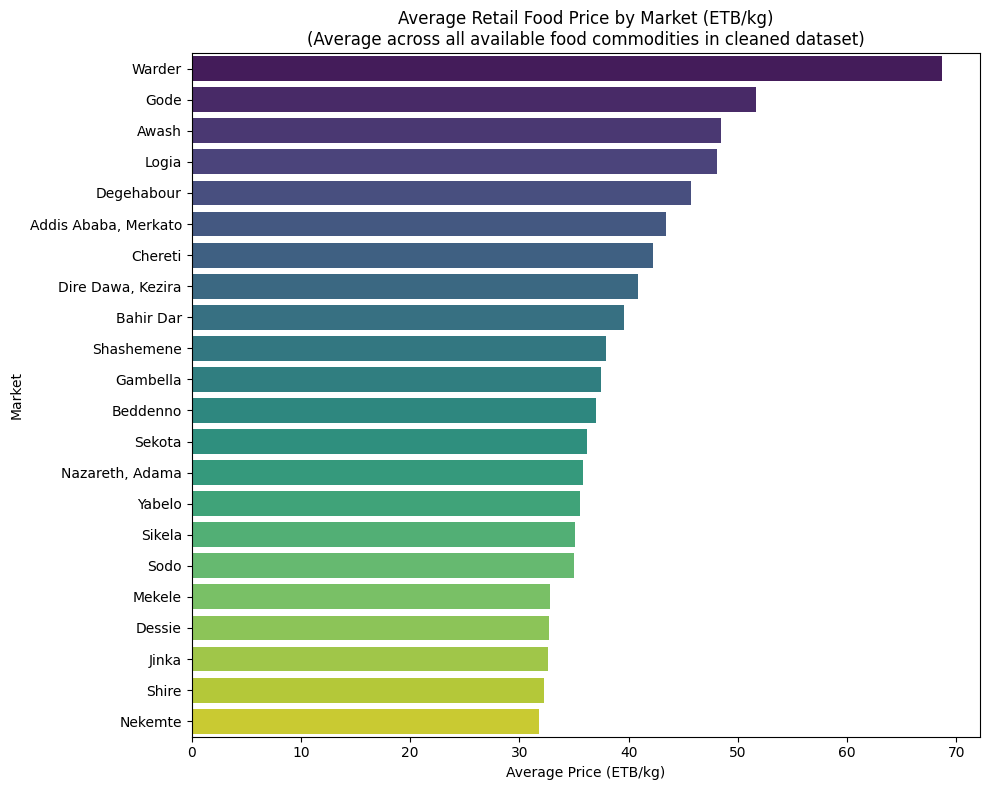

In [6]:
plt.figure(figsize=(10, 8))
sns.barplot(
    x='average_price_etb_per_kg', 
    y='market', 
    data=avg_price_market, 
    palette='viridis'
)
plt.title('Average Retail Food Price by Market (ETB/kg)\n(Average across all available food commodities in cleaned dataset)')
plt.xlabel('Average Price (ETB/kg)')
plt.ylabel('Market')
plt.tight_layout()
plt.savefig('../images/average_price_by_market.png')
plt.show()


## 7. Visualization 2 — Commodity × Market Heatmap


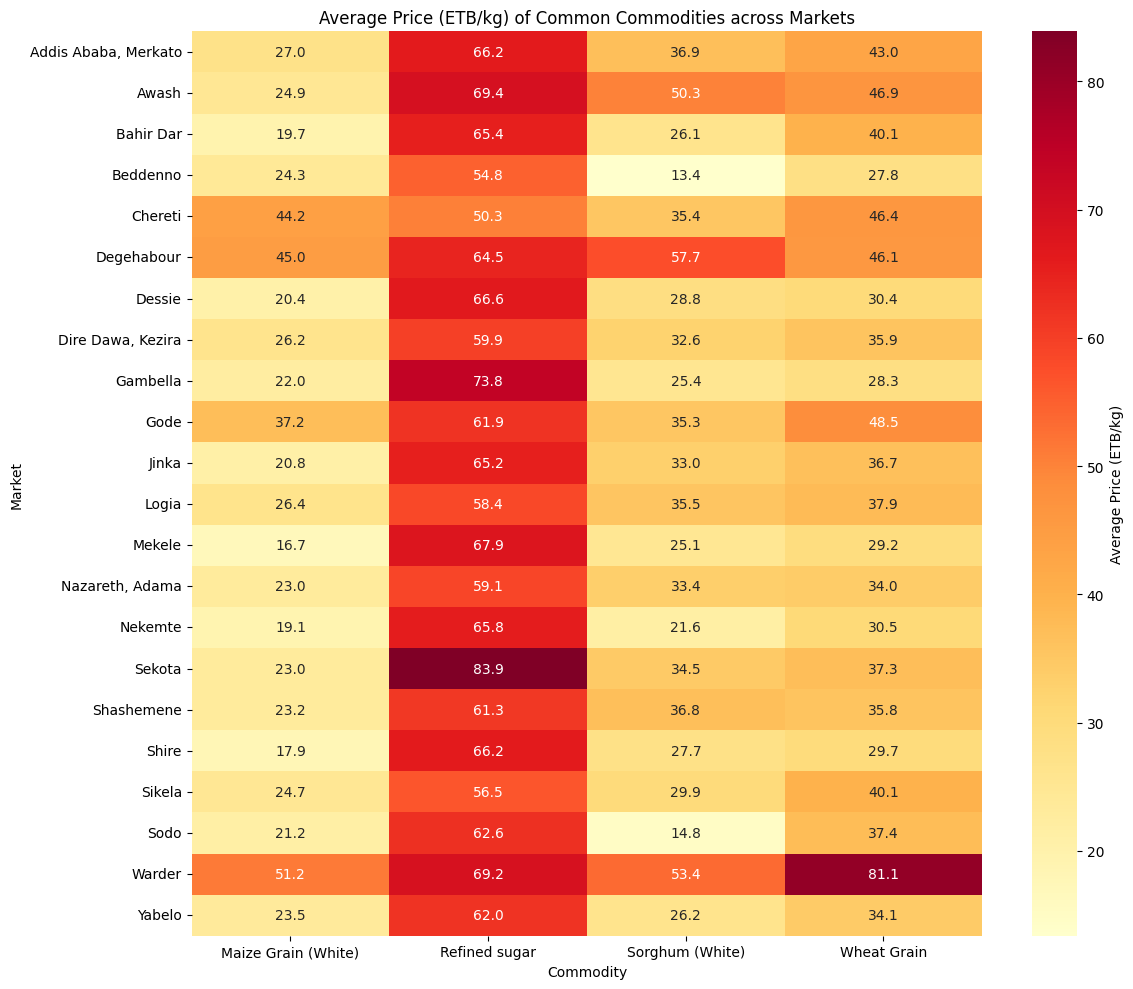

In [7]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    market_product_avg, 
    cmap='YlOrRd', 
    annot=True, 
    fmt=".1f", 
    cbar_kws={'label': 'Average Price (ETB/kg)'}
)
plt.title('Average Price (ETB/kg) of Common Commodities across Markets')
plt.xlabel('Commodity')
plt.ylabel('Market')
plt.tight_layout()
plt.savefig('../images/commodity_market_heatmap.png')
plt.show()


## Location Analysis Findings

Based on the calculated results from the dataset:

1. **Highest overall average price:** Warder has the highest overall average price at approximately 68.73 ETB/kg.
2. **Lowest overall average price:** Nekemte has the lowest overall average price at approximately 31.80 ETB/kg.
3. **Price difference:** The difference between the highest and lowest average market price is about 36.93 ETB/kg.
4. **Most observations:** The markets with the most observations are Addis Ababa (Merkato) with 2138 observations, followed by Nazareth (Adama) with 1945 observations, and Shashemene with 1852 observations.
5. **Selected commodities:** 'Maize Grain (White)', 'Refined sugar', 'Sorghum (White)', and 'Wheat Grain' were selected because they are present in all 22 markets.
6. **Relative prices for selected commodities:** For the selected commodities, Warder, Gode, and Degehabour consistently show relatively higher prices. Markets like Nekemte, Shire, and Dessie tend to show lower prices.
7. **Consistent patterns:** Yes, Warder is consistently higher across several commodities (e.g., Refined sugar is 134.4 ETB/kg in Warder compared to ~60-70 in most others; Wheat Grain is 81.1 in Warder compared to ~30-40 in others).


## Data Limitations

- **Market averages depend on available observations:** A market's overall average is heavily influenced by which specific commodities are recorded there.
- **Availability varies:** Not every commodity is available in every market. If expensive goods are recorded in one market and not another, the average will skew higher.
- **Scope:** The analysis is based purely on the cleaned kg + Retail dataset.
- **Causality:** Average prices do not prove *why* a market is more or less expensive (e.g., we cannot assert it's due to transport costs or demand without further data).
